# CODE TO PERFORM SIMPLE LINEAR REGRESSION ON FUEL CONSUMPTION DATASET


# PROBLEM STATEMENT

- You have been hired as a consultant to a major Automotive Manufacturer and you have been tasked to develop a model to predict the impact of increasing the vehicle horsepower (HP) on fuel economy (Mileage Per Gallon (MPG)). You gathered the data:
- Data set:
    - Independant variable X: Vehicle Horse Power 
    - Dependant variable Y: Mileage Per Gallon (MPG) 

# STEP #1: LIBRARIES IMPORT


In [195]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# STEP #2: IMPORT DATASET

In [196]:
data = pd.read_csv('FuelEconomy.csv')

In [197]:
data.head(5)

,Horse Power,Fuel Economy (MPG)
0,118.770799,29.344195
1,176.326567,24.695934
2,219.262465,23.952010
3,187.310009,23.384546
4,218.594340,23.426739


In [198]:
data.tail(5)

,Horse Power,Fuel Economy (MPG)
95,162.810542,27.418661
96,266.869640,15.989945
97,243.831211,19.253375
98,140.959803,29.515593
99,184.123053,25.196097


In [199]:
data.describe()

,Horse Power,Fuel Economy (MPG)
count,100.000000,100.000000
mean,213.676190,23.178501
std,62.061726,4.701666
min,50.000000,10.000000
25%,174.996514,20.439516
50%,218.928402,23.143192
75%,251.706476,26.089933
max,350.000000,35.000000


In [200]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Horse Power         100 non-null    float64
 1   Fuel Economy (MPG)  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


# STEP#3: VISUALIZE DATASET

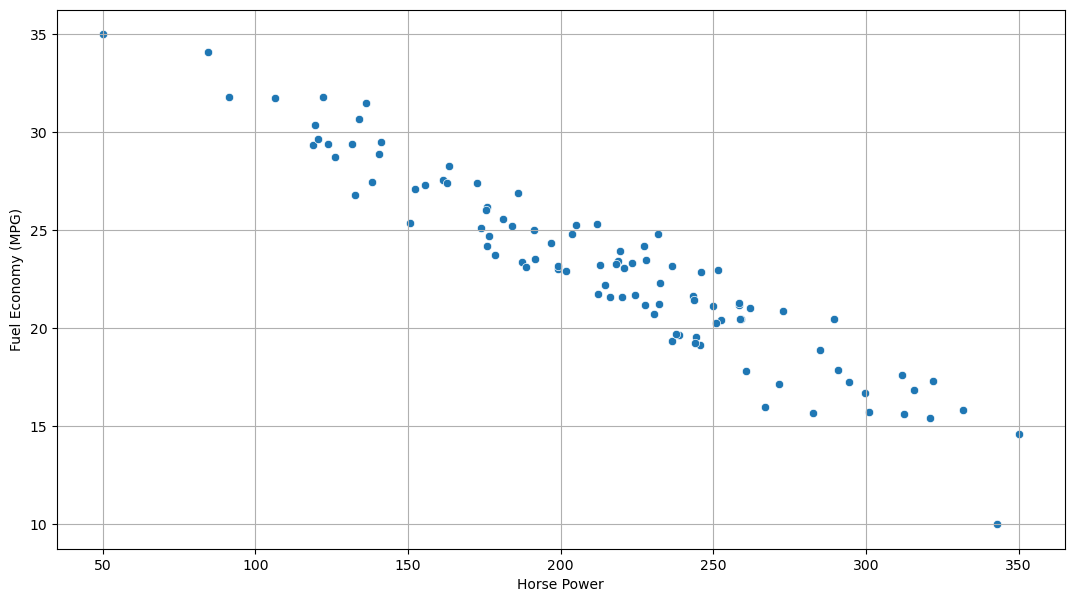

In [201]:
plt.figure(figsize=(13,7))
sns.scatterplot(x= 'Horse Power', y= 'Fuel Economy (MPG)', data=data)
plt.grid()

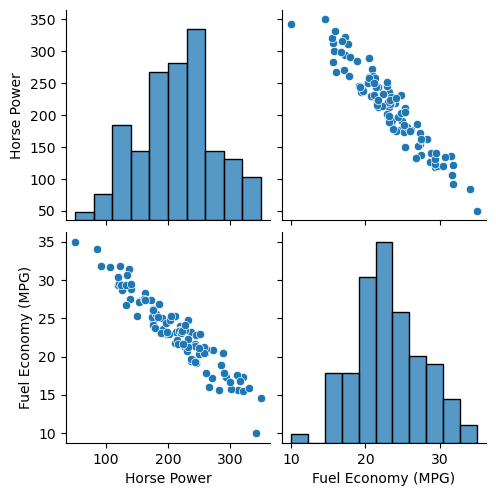

In [202]:
sns.pairplot(data)

<AxesSubplot: xlabel='Horse Power', ylabel='Fuel Economy (MPG)'>

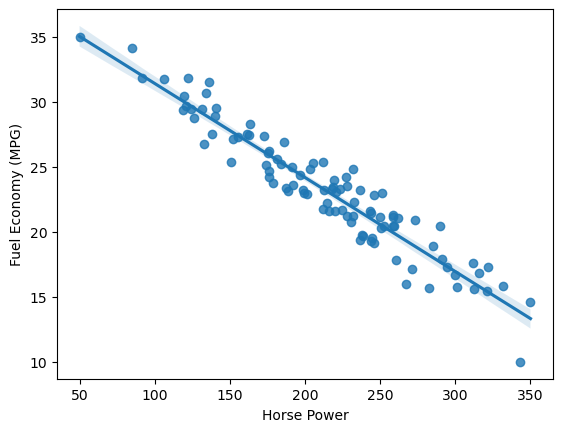

In [203]:
sns.regplot(x = 'Horse Power', y = 'Fuel Economy (MPG)', data = data)

# STEP#4: CREATE TESTING AND TRAINING DATASET

In [204]:
X = data['Horse Power']
y = data['Fuel Economy (MPG)']
print(X, y)

0     118.770799
1     176.326567
2     219.262465
3     187.310009
4     218.594340
         ...    
95    162.810542
96    266.869640
97    243.831211
98    140.959803
99    184.123053
Name: Horse Power, Length: 100, dtype: float64 0     29.344195
1     24.695934
2     23.952010
3     23.384546
4     23.426739
        ...    
95    27.418661
96    15.989945
97    19.253375
98    29.515593
99    25.196097
Name: Fuel Economy (MPG), Length: 100, dtype: float64


In [205]:
##make arrays
X=np.array(X)
y=np.array(y)
print(X, y)

[118.7707988  176.3265674  219.2624649  187.3100089  218.5943396
 175.8381062  271.4416078  294.4259159  126.2110081  163.3503346
 321.840752   120.4842359  155.4153676  191.7148134  211.7291092
 259.1831915  236.5717375  191.0989631  123.8856983  136.3064532
 212.7389563  232.4499479  122.0401613  140.4323131  243.3478332
 178.4302897  258.4242233  231.8549017   91.44026398 119.5366581
 350.         175.9792193  312.4922095  282.6042464  138.2647325
 301.0541818  227.8735033   50.         152.3478571  252.5523857
 218.107081   172.6436613  243.737242   186.0400447  227.6704653
 132.6695695  196.8595414  244.3583428  161.4110712  133.8230607
 150.5062473  290.8871997  245.8204064  250.7092886  272.9057433
 199.1476381  251.4245057  284.9285944  201.62646    173.9393164
 230.4626774  289.4900032  220.7209461  212.0830389  188.5052266
 181.0679338  245.559651    84.57199234 311.7574323  315.8174983
 223.1796492  299.5304577  175.348913   261.8521099  258.3083455
 220.0985859  214.484493 

In [206]:
##reshape it
X= X.reshape(-1,1)
y= y.reshape(-1,1)
print(X,y)


[[118.7707988 ]
 [176.3265674 ]
 [219.2624649 ]
 [187.3100089 ]
 [218.5943396 ]
 [175.8381062 ]
 [271.4416078 ]
 [294.4259159 ]
 [126.2110081 ]
 [163.3503346 ]
 [321.840752  ]
 [120.4842359 ]
 [155.4153676 ]
 [191.7148134 ]
 [211.7291092 ]
 [259.1831915 ]
 [236.5717375 ]
 [191.0989631 ]
 [123.8856983 ]
 [136.3064532 ]
 [212.7389563 ]
 [232.4499479 ]
 [122.0401613 ]
 [140.4323131 ]
 [243.3478332 ]
 [178.4302897 ]
 [258.4242233 ]
 [231.8549017 ]
 [ 91.44026398]
 [119.5366581 ]
 [350.        ]
 [175.9792193 ]
 [312.4922095 ]
 [282.6042464 ]
 [138.2647325 ]
 [301.0541818 ]
 [227.8735033 ]
 [ 50.        ]
 [152.3478571 ]
 [252.5523857 ]
 [218.107081  ]
 [172.6436613 ]
 [243.737242  ]
 [186.0400447 ]
 [227.6704653 ]
 [132.6695695 ]
 [196.8595414 ]
 [244.3583428 ]
 [161.4110712 ]
 [133.8230607 ]
 [150.5062473 ]
 [290.8871997 ]
 [245.8204064 ]
 [250.7092886 ]
 [272.9057433 ]
 [199.1476381 ]
 [251.4245057 ]
 [284.9285944 ]
 [201.62646   ]
 [173.9393164 ]
 [230.4626774 ]
 [289.4900032 ]
 [220.72

In [207]:
from sklearn.model_selection import train_test_split

In [208]:
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.25)

# STEP#5: TRAIN THE MODEL

In [209]:
X_train.shape

(75, 1)

In [210]:
X_test.shape

(25, 1)

In [211]:
y_train.shape

(75, 1)

In [212]:
y_test.shape

(25, 1)

In [213]:
from sklearn.linear_model import LinearRegression


In [214]:
SimpleReg = LinearRegression(fit_intercept=True)
SimpleReg.fit(X_train, y_train)

LinearRegression()

In [215]:
print('Linear Model Coef (m)', SimpleReg.coef_)
print('Linear Model Coef (b)', SimpleReg.intercept_)

Linear Model Coef (m) [[-0.07413329]]
Linear Model Coef (b) [39.05163259]


# STEP#6: TEST THE MODEL 

In [216]:
y_predict = SimpleReg.predict(X_test)
print(y_predict.flatten())

[15.19251723 17.92893709 30.1197392  25.16572447 16.73349417 26.98195071
 22.68886162 22.15861898 21.51379022 22.84651396 20.98258777 25.82400731
 32.78203214 26.15693796 20.5269086  24.10439878 25.07711905 19.8763236
 26.00571324 20.32909212 16.84645286 24.88483681 27.89410858 29.69519471
 30.24676194]


In [217]:
y_test

array([[17.30062804],
       [18.87834992],
       [29.67863744],
       [23.38454579],
       [15.72564969],
       [27.41866055],
       [23.05917995],
       [23.48881057],
       [23.18528033],
       [23.42673926],
       [21.44270298],
       [23.71958332],
       [34.11402465],
       [25.12965002],
       [21.13942912],
       [22.93765296],
       [23.1141609 ],
       [20.4706756 ],
       [26.18847756],
       [20.40757083],
       [16.69336865],
       [24.98962965],
       [25.34563185],
       [28.71821022],
       [29.34419493]])

Text(0.5, 1.0, 'Horse v fuel Training plot')

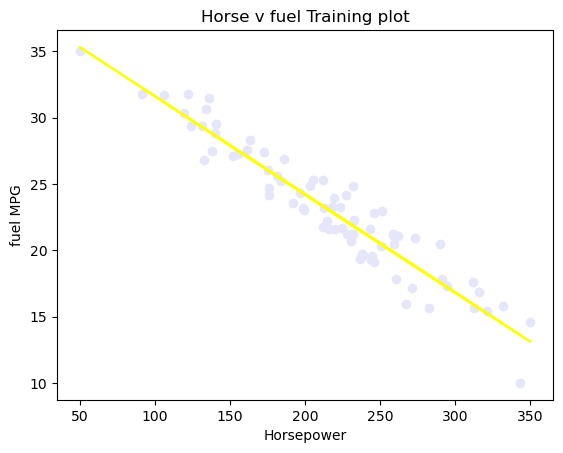

In [218]:
plt.scatter(X_train,y_train, color='lavender')
plt.plot(X_train, SimpleReg.predict(X_train), color='yellow')
plt.ylabel('fuel MPG')
plt.xlabel('Horsepower')
plt.title('Horse v fuel Training plot')

Text(0.5, 1.0, 'Horse v fuel test plot')

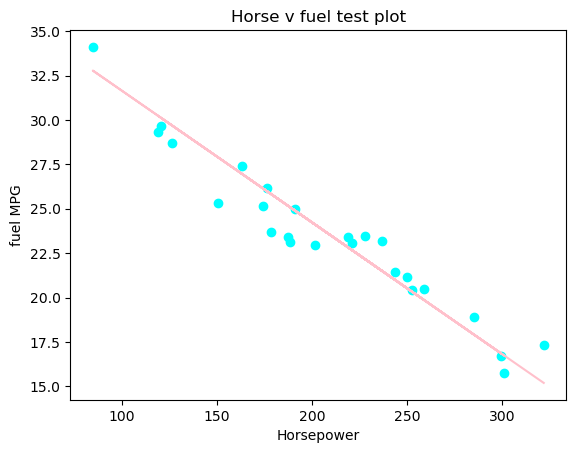

In [219]:
plt.scatter(X_test,y_test, color='aqua')
plt.plot(X_test, SimpleReg.predict(X_test), color='pink')
plt.ylabel('fuel MPG')
plt.xlabel('Horsepower')
plt.title('Horse v fuel test plot')

In [222]:
###testing model with horsepower 300 
Hone =np.array([150])
Hone = Hone.reshape(-1,1)

fuelHone= SimpleLinearRegression.predict(Hone)
print('fuelHone', fuelHone)

fuelHone [[27.77343918]]


# EXCELLENT JOB! NOW YOU BECAME EXPERT IN SIMPLE LINEAR REGRESSION

In [ ]:
Have a nice day!